# Étape 6 : Évaluation finale & Interprétabilité

## Objectif
Comparer tous les modèles sur les mêmes métriques, puis utiliser SHAP 
pour comprendre POURQUOI notre meilleur modèle (XGBoost + Pondération) 
flag une transaction comme frauduleuse.

L'interprétabilité est essentielle en anti-fraude : une banque ne peut 
pas bloquer la carte d'un client en disant "l'algorithme a dit fraude". 
Il faut pouvoir expliquer quelles caractéristiques ont déclenché l'alerte.

## 6.1 — Imports et rechargement de tous les modèles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)

# Chargement des données
with open('../outputs/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Réentraînement du meilleur modèle : XGBoost + Pondération
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

best_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=== XGBOOST + PONDÉRATION (modèle retenu) ===")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba):.3f}")

=== XGBOOST + PONDÉRATION (modèle retenu) ===
Precision : 0.874
Recall    : 0.847
F1-Score  : 0.860
AUC-ROC   : 0.975


## 6.2 — Interprétabilité avec SHAP

### Pourquoi SHAP ?

Un modèle de détection de fraude ne peut pas être une boîte noire. Quand 
une transaction est bloquée, la banque doit pouvoir expliquer pourquoi 
au client et au régulateur.

SHAP (SHapley Additive exPlanations) décompose chaque prédiction 
feature par feature : il indique quelles caractéristiques ont poussé 
le modèle vers "fraude" et lesquelles ont poussé vers "légitime", 
avec leur poids respectif.

Trois niveaux d'analyse :
- **Importance globale** : quelles features comptent le plus en général
  pour le modèle.
- **Beeswarm** : comment la valeur de chaque feature (haute ou basse) 
  influence la prédiction.
- **Waterfall** : explication détaillée d'une transaction précise — 
  le "procès-verbal" de la décision du modèle.

=== SHAP — Feature Importance Globale ===


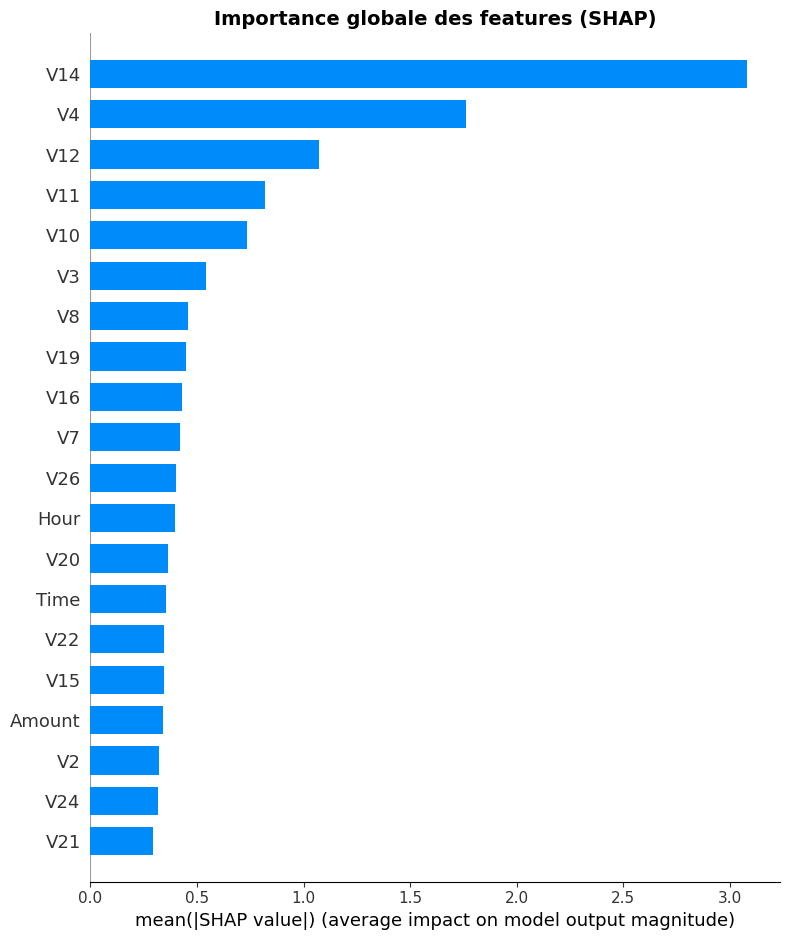

In [2]:
# SHAP explique la contribution de chaque feature à chaque prédiction
# On utilise un échantillon du test (SHAP est coûteux en calcul)
X_test_sample = X_test.sample(n=1000, random_state=42)

# Création de l'explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

# 1. Importance globale : quelles features comptent le plus ?
print("=== SHAP — Feature Importance Globale ===")
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('Importance globale des features (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse — Importance globale des features (SHAP)

**V14** domine largement avec un impact moyen de ~3.0, ce qui confirme 
les observations de l'EDA où V14 avait la plus forte corrélation 
négative avec la fraude (-0.30). C'est la feature la plus déterminante 
dans la décision du modèle.

**V4** arrive en 2ème position — c'est une surprise. Sa corrélation 
avec Class était modérée (+0.13) à l'EDA, mais SHAP révèle qu'elle 
capture des relations non linéaires et des interactions avec d'autres 
features que la corrélation simple ne détectait pas. C'est exactement 
la force d'un modèle comme XGBoost par rapport à une approche linéaire.

**V12** en 3ème position confirme l'EDA (corrélation de -0.26).

**Hour**, notre feature créée lors du feature engineering, apparaît dans 
le top 12. Cela valide notre choix de transformer Time en heure de la 
journée — le modèle exploite cette information pour ses prédictions.

**Amount** en revanche a un impact faible, ce qui confirme notre 
observation lors de l'EDA : le montant seul ne distingue pas bien 
les fraudes des transactions légitimes.

## 6.3 — SHAP : vue détaillée (beeswarm plot)

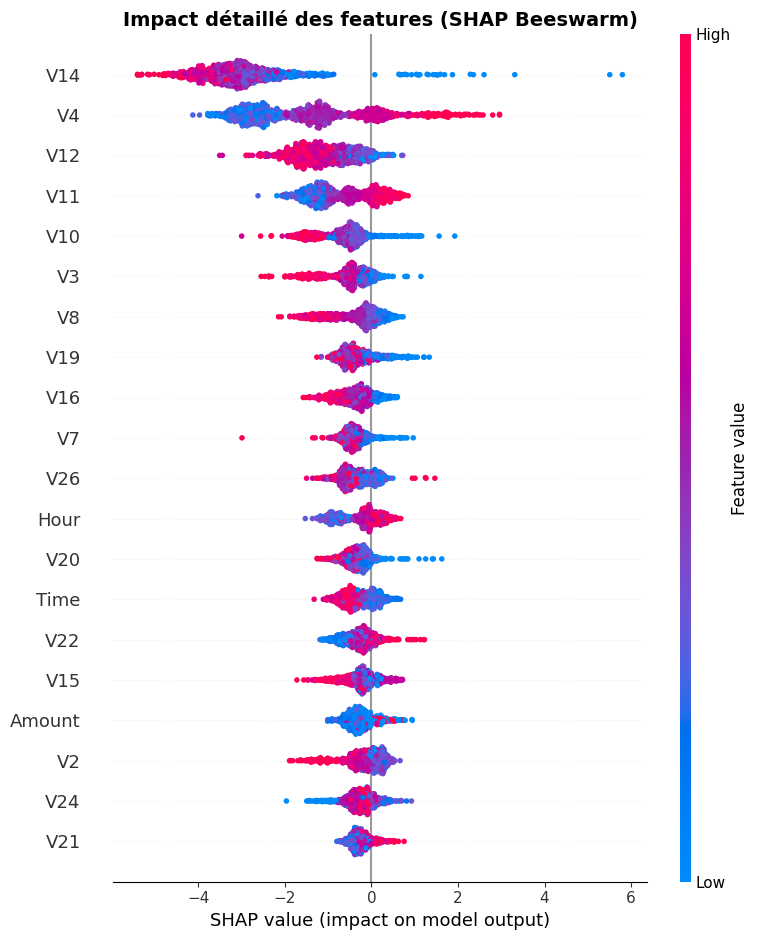

In [3]:
# Ce graphique montre COMMENT chaque feature impacte la prédiction
# Rouge = valeur élevée, Bleu = valeur faible
# À droite = pousse vers "fraude", À gauche = pousse vers "légitime"
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('Impact détaillé des features (SHAP Beeswarm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse — Beeswarm (impact détaillé)

Ce graphique montre pour chaque transaction comment la valeur de chaque 
feature influence la prédiction. Chaque point est une transaction : 
rouge = valeur élevée, bleu = valeur basse. Position à droite = pousse 
vers "fraude", à gauche = pousse vers "légitime".

**V14** : les valeurs basses (bleu) poussent fortement vers "fraude" 
(points à gauche, SHAP très négatif). Confirmé par l'EDA (corrélation 
négative).

**V4** : les valeurs hautes (rouge) poussent vers "fraude" (points à 
droite). Confirmé par la corrélation positive de l'EDA.

**V12, V10** : même pattern que V14 — valeurs basses = suspicion de fraude.

**Hour** : impact modéré mais présent, validant l'utilité de notre 
feature engineering.

## 6.4 — SHAP : explication d'une transaction frauduleuse

In [9]:
# Debug
fraud_indices = X_test_sample.index[y_test.loc[X_test_sample.index] == 1]
print(f"Nombre de fraudes dans l'échantillon : {len(fraud_indices)}")

Nombre de fraudes dans l'échantillon : 0


=== Explication de la transaction #77348 (FRAUDE) ===
Probabilité de fraude prédite : 1.000


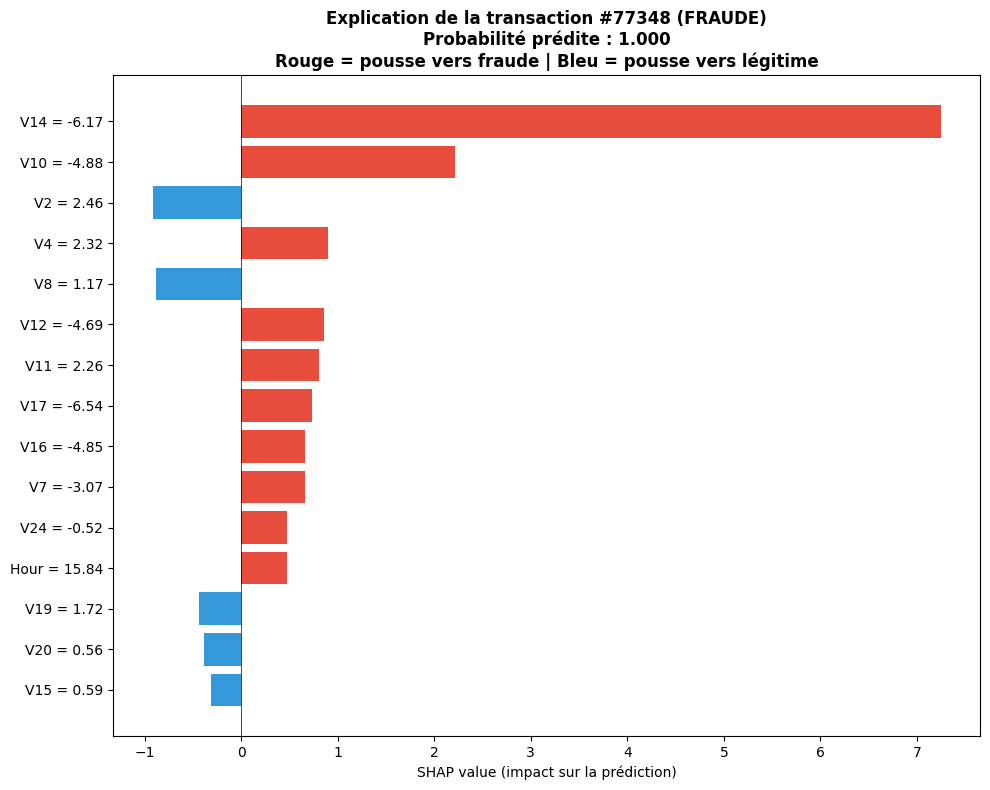

In [10]:
# Échantillon incluant des fraudes
X_test_fraud = X_test[y_test == 1].head(5)
X_test_legit = X_test[y_test == 0].sample(n=995, random_state=42)
X_test_mixed = pd.concat([X_test_fraud, X_test_legit])

# Recalcul SHAP sur cet échantillon
shap_values_mixed = explainer.shap_values(X_test_mixed)

# Première fraude
fraud_position = 0
fraud_idx = X_test_mixed.index[fraud_position]
proba = best_model.predict_proba(X_test_mixed.iloc[[fraud_position]])[:, 1][0]

print(f"=== Explication de la transaction #{fraud_idx} (FRAUDE) ===")
print(f"Probabilité de fraude prédite : {proba:.3f}")

# Visualisation
feature_names = X_test_mixed.columns.tolist()
shap_vals = shap_values_mixed[fraud_position]

top_idx = np.argsort(np.abs(shap_vals))[-15:]
top_features = [feature_names[i] for i in top_idx]
top_shap = [shap_vals[i] for i in top_idx]
top_data = [X_test_mixed.iloc[fraud_position, i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_shap]
labels = [f"{name} = {val:.2f}" for name, val in zip(top_features, top_data)]
ax.barh(labels, top_shap, color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('SHAP value (impact sur la prédiction)')
ax.set_title(f'Explication de la transaction #{fraud_idx} (FRAUDE)\n'
             f'Probabilité prédite : {proba:.3f}\n'
             f'Rouge = pousse vers fraude | Bleu = pousse vers légitime',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse — Explication d'une transaction frauduleuse (#77348)

Le modèle prédit cette transaction comme fraude avec une probabilité de 100%.

Les principaux facteurs de cette décision :
- **V14 = -6.17** : contribution SHAP de +7, facteur dominant. Valeur 
  très basse, fortement associée à la fraude.
- **V10 = -4.88** : deuxième contributeur (SHAP ≈ +2), même pattern.
- **V4, V12, V11** : contributions modérées vers la fraude.

Quelques features poussent vers "légitime" (V2, V8, V19) mais leur 
poids est largement insuffisant pour contrebalancer les signaux de fraude.

Ce type d'explication est exactement ce qu'une banque peut utiliser 
pour justifier le blocage d'une transaction auprès d'un client ou 
d'un régulateur.